# 04 – FEM / REM / Hausman Test


| # | Lỗi | Hậu quả | Cách sửa |
|---|-----|---------|----------|
| 1 | **Zero migration lẫn vào `data_clean`** – `migration=0` → `ln_migration=−23` | Outlier cực đoan kéo hệ số sai | Lọc chặt `migration > 0` trước khi log |
| 2 | **CO₂ năm 2024 = 0** – dữ liệu chưa có, interpolation ngoại suy thất bại | `ln_co2 = −23`, within variance 4.84× bình thường | Loại năm 2024 hoặc thay NaN, không dùng ln_co2 2024 |
| 3 | **PM2.5 = 0 từ 2021–2024** (365 obs/năm) – tương tự CO₂ | `ln_pm25 = −23`, distortion FEM demeaning | Thay 0→NaN, loại khỏi hồi quy hoặc giới hạn mẫu ≤2020 |
| 4 | **Multicollinearity GDP = GDPpc × Pop** – `corr(ln_gdp, ln_gdppc+ln_pop) = 0.95` | SE phồng, hệ số bất ổn, dấu sai | Chọn **một** trong hai: giữ `ln_gdppc` + `ln_pop`, bỏ `ln_gdp` |
| 5 | **Two-way FEM hấp thụ quá nhiều variation** – 365 pairs × 25 năm FE, within/total = 0.24 | R² within thấp, nhiều hệ số không có ý nghĩa | Dùng **One-way FEM** (pair FE) + year dummies rời rạc |
| 6 | **`ln_bandwidth_org` = 0** (1921 obs) và **`ln_internet` = 0** (235 obs) – log(1)=0 do thay 0→1 trước khi log | Zeros giả, nhiễu trong FEM | Thay bằng NaN, dùng `ln1p` hoặc loại khỏi spec cơ bản |

## 0. Import thư viện

In [2]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

try:
    from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects
    from linearmodels.panel.results import compare
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable,'-m','pip','install','linearmodels','-q'])
    from linearmodels.panel import PooledOLS, PanelOLS, RandomEffects
    from linearmodels.panel.results import compare

import statsmodels.api as sm

os.makedirs('../output/figures', exist_ok=True)
os.makedirs('../output/tables',  exist_ok=True)

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 25)
plt.rcParams.update({'figure.dpi':120, 'font.size':11})
SEED = 42
np.random.seed(SEED)
print('✅ Import OK')

✅ Import OK


## 1. Load dữ liệu

In [3]:
df_raw = pd.read_csv('../data/processed/data_clean_pca.csv', low_memory=False)
print(f'Shape gốc: {df_raw.shape}')
print(f'Years: {sorted(df_raw.year.unique().tolist())}')
print(f'Pairs: {df_raw.pair_id.nunique()}')

Shape gốc: (9125, 80)
Years: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Pairs: 365


## 2. Sửa lỗi dữ liệu trước khi hồi quy

### 2.1 Lọc zero migration & giới hạn mẫu ≤ 2022

In [4]:
df = df_raw.copy()

# ── FIX 1: Loại zero migration (chỉ giữ migration > 0) ──────────────────
n0 = len(df)
df = df[df['migration'] > 0].copy()
print(f'Fix 1 – Bỏ zero migration: -{n0-len(df)} obs (còn {len(df):,})')

# ── FIX 2 & 3: Giới hạn mẫu 2000-2022 (CO2/PM2.5 chưa có từ 2023+) ────
n1 = len(df)
df = df[df['year'].between(2000, 2022)].copy()
print(f'Fix 2&3 – Giới hạn 2000-2022: -{n1-len(df)} obs (còn {len(df):,})')

# ── FIX 3b: PM2.5 = 0 từ 2021-2022 → NaN ────────────────────────────────
n_pm25_zero = (df['pm25_org'] == 0).sum()
df.loc[df['pm25_org'] == 0, 'pm25_org'] = np.nan
df.loc[df['pm25_org'].isna(), 'ln_pm25_org'] = np.nan
print(f'Fix 3b – PM2.5 zero→NaN: {n_pm25_zero} obs')

# ── FIX 2b: CO2 = 0 → NaN (nếu còn) ─────────────────────────────────────
n_co2_zero = (df['co2_org'] == 0).sum()
df.loc[df['co2_org'] == 0, 'co2_org'] = np.nan
df.loc[df['co2_org'].isna(), 'ln_co2_org'] = np.nan
print(f'Fix 2b – CO2 zero→NaN: {n_co2_zero} obs')

# ── FIX 6: bandwidth/internet = 0 → NaN ──────────────────────────────────
for col, ln_col in [('bandwidth_org','ln_bandwidth_org'),('internet_use_org','ln_internet_use_org')]:
    n_z = (df[ln_col] == 0).sum()
    df.loc[df[ln_col] == 0, ln_col] = np.nan
    print(f'Fix 6 – {ln_col} zero→NaN: {n_z} obs')

# ── Tái tạo ln_migration từ migration > 0 ────────────────────────────────
df['ln_migration'] = np.log(df['migration'])
print(f'\nln_migration range: [{df["ln_migration"].min():.2f}, {df["ln_migration"].max():.2f}]')
print(f'Sample cuối: {len(df):,} obs | {df["pair_id"].nunique()} pairs | {df["year"].nunique()} years')

Fix 1 – Bỏ zero migration: -38 obs (còn 9,087)
Fix 2&3 – Giới hạn 2000-2022: -727 obs (còn 8,360)
Fix 3b – PM2.5 zero→NaN: 894 obs
Fix 2b – CO2 zero→NaN: 0 obs
Fix 6 – ln_bandwidth_org zero→NaN: 1301 obs
Fix 6 – ln_internet_use_org zero→NaN: 52 obs

ln_migration range: [1.61, 14.71]
Sample cuối: 8,360 obs | 364 pairs | 23 years


In [5]:
# Xác định tên file và đường dẫn lưu
# Bạn có thể thay đổi đường dẫn phù hợp với thư mục của mình
output_path = 'migration_data_processed_2000_2022.csv'

# Lưu file (index=False để không tạo thêm cột số thứ tự hàng dư thừa)
df.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"✅ Đã lưu file thành công tại: {output_path}")
print(f"📊 Tổng số dòng: {len(df):,}")
print(f"📊 Các cột quan trọng: ln_migration, ln_pm25_org, ln_co2_org...")

✅ Đã lưu file thành công tại: migration_data_processed_2000_2022.csv
📊 Tổng số dòng: 8,360
📊 Các cột quan trọng: ln_migration, ln_pm25_org, ln_co2_org...


### 2.2 Fix 4 – Multicollinearity: bỏ `ln_gdp_org/des`, giữ `ln_gdppc` + `ln_pop`

In [23]:
# GDP = GDPpc * Pop → ln_gdp = ln_gdppc + ln_pop (gần đúng)
# Đưa cả ba vào mô hình gây near-perfect multicollinearity
# → Giữ ln_gdppc (mức sống) + ln_pop (quy mô) theo chuẩn gravity migration

corr_check = df['ln_gdp_org'].corr(df['ln_gdppc_org'] + df['ln_pop_org'])
print(f'corr(ln_gdp_org, ln_gdppc_org+ln_pop_org) = {corr_check:.4f}')
print('→ Loại ln_gdp_org và ln_gdp_des khỏi hồi quy, giữ ln_gdppc + ln_pop')

corr(ln_gdp_org, ln_gdppc_org+ln_pop_org) = 0.9532
→ Loại ln_gdp_org và ln_gdp_des khỏi hồi quy, giữ ln_gdppc + ln_pop


### 2.3 Fix 5 – One-way FEM + explicit year dummies

In [24]:
# Thêm year dummies rời rạc (ref = 2000)
# Thay vì time_effects=True trong PanelOLS (two-way),
# ta dùng entity effects (pair FE) + explicit yr_* dummies
# → kiểm soát được year effects nhưng vẫn estimate được

# 🔥 Xóa toàn bộ year dummies cũ nếu tồn tại
df = df.loc[:, ~df.columns.str.startswith('yr_')]

# Tạo lại từ đầu
yr_dummies = pd.get_dummies(df['year'], prefix='yr', drop_first=True).astype(float)

df = pd.concat([df, yr_dummies], axis=1)

yr_cols = yr_dummies.columns.tolist()

print(f'Year dummies: {len(yr_cols)} cột ({yr_cols[0]} đến {yr_cols[-1]})')
print('Ref year: 2000')

Year dummies: 22 cột (yr_2001 đến yr_2022)
Ref year: 2000


## 3. Định nghĩa đặc tả mô hình

| Spec | Tên | Biến |
|------|-----|------|
| M1 | Gravity cơ bản | GDPpc, Pop, Dist, Lang, Contig, Colony |
| M2 | Gravity đầy đủ | M1 + Internet, CO2, PM2.5, Disaster, Inflation |
| M3 | Gravity + Year FE | M2 + year dummies |

> **Lưu ý:** `ln_dist`, `comlang_off`, `contig`, `colony` là **time-invariant** → bị hấp thụ vào entity FE.
> Chúng chỉ ước lượng được trong POLS và REM.

In [25]:
DEP_VAR = 'ln_migration'

# Biến thay đổi theo thời gian (time-varying) → FEM ước lượng được
TIME_VARYING = [
    'ln_gdppc_org',       # GDPpc nước gốc – push factor kinh tế
    'ln_gdppc_des',       # GDPpc nước đến – pull factor
    'ln_pop_org',         # Dân số nước gốc
    'ln_pop_des',         # Dân số nước đến
    'inflation_org',      # Lạm phát nước gốc – bất ổn
    'inflation_des',
    'ln_internet_use_org',# Số hóa nước gốc
    'ln_disaster_org',    # Thiên tai nước gốc
    'ln_disaster_des',
]

# Biến time-invariant → chỉ POLS/REM
TIME_INVARIANT = ['ln_dist', 'comlang_off', 'contig', 'colony']

# ── Đặc tả ──
SPEC_M1_TV  = ['ln_gdppc_org','ln_gdppc_des','ln_pop_org','ln_pop_des']  # time-varying trong M1
SPEC_M1_ALL = SPEC_M1_TV + TIME_INVARIANT  # cho POLS/REM

SPEC_M2_TV  = TIME_VARYING                 # đầy đủ time-varying
SPEC_M2_ALL = TIME_VARYING + TIME_INVARIANT + ['ln_co2_org','ln_pm25_org']

SPEC_M3_TV  = TIME_VARYING + yr_cols       # M2 + year FE explicit

print('M1 (time-varying):', SPEC_M1_TV)
print('M2 (time-varying):', SPEC_M2_TV)
print('M3 = M2 + year dummies')

M1 (time-varying): ['ln_gdppc_org', 'ln_gdppc_des', 'ln_pop_org', 'ln_pop_des']
M2 (time-varying): ['ln_gdppc_org', 'ln_gdppc_des', 'ln_pop_org', 'ln_pop_des', 'inflation_org', 'inflation_des', 'ln_internet_use_org', 'ln_disaster_org', 'ln_disaster_des']
M3 = M2 + year dummies


## 4. Tạo Panel Index

In [26]:
def make_panel(data):
    d = data.copy()
    d['pair_id'] = d['pair_id'].astype(str)
    return d.set_index(['pair_id','year'])

panel = make_panel(df)
print(f'Panel: {panel.shape[0]:,} obs | index: {panel.index.names}')
print(f'Missing ln_migration: {panel[DEP_VAR].isna().sum()}')

Panel: 8,360 obs | index: ['pair_id', 'year']
Missing ln_migration: 0


## 5. Hàm hồi quy & kiểm định

In [27]:
def run_pols(panel_df, dep, indep):
    d = panel_df[[dep]+indep].dropna()
    y = d[dep]
    X = sm.add_constant(d[indep])
    return PooledOLS(y, X).fit(cov_type='clustered', cluster_entity=True)

def run_fem(panel_df, dep, indep, time_effects=False):
    """One-way FEM (entity/pair effects). time_effects=False → year dummies đã thêm tường minh."""
    d = panel_df[[dep]+indep].dropna()
    y = d[dep]
    X = d[indep]  # không thêm const cho FEM
    mod = PanelOLS(y, X, entity_effects=True, time_effects=time_effects, drop_absorbed=True)
    return mod.fit(cov_type='clustered', cluster_entity=True)

def run_rem(panel_df, dep, indep):
    d = panel_df[[dep]+indep].dropna()
    y = d[dep]
    X = sm.add_constant(d[indep])
    return RandomEffects(y, X).fit(cov_type='clustered', cluster_entity=True)

def hausman_test(fem_res, rem_res):
    common = list(fem_res.params.index.intersection(rem_res.params.index))
    common = [v for v in common if v not in ['const','Intercept']]
    if not common:
        return {'error':'No common vars'}
    b_fe  = fem_res.params[common].values
    b_re  = rem_res.params[common].values
    diff  = b_fe - b_re
    V_fe  = fem_res.cov.loc[common,common].values
    V_re  = rem_res.cov.loc[common,common].values
    V_d   = V_fe - V_re
    try:    Vi = np.linalg.inv(V_d)
    except: Vi = np.linalg.pinv(V_d)
    stat  = float(diff @ Vi @ diff)
    df_   = len(common)
    pval  = 1 - stats.chi2.cdf(abs(stat), df_)
    concl = 'FEM ưa thích (p<0.05)' if pval < 0.05 else 'REM ưa thích (p≥0.05)'
    return {'stat':round(stat,4),'df':df_,'pval':round(pval,6),'conclusion':concl,'vars':common}

def print_hausman(h, label=''):
    print('\n' + '='*55)
    print(f'  HAUSMAN TEST – {label}')
    print('\n' + '='*55)
    if 'error' in h: print('  Lỗi:', h['error']); return
    print(f'  Chi² = {h["stat"]:.4f} | df = {h["df"]} | p = {h["pval"]:.6f}')
    print(f'  → {h["conclusion"]}')
    print(f'\n' + '='*55)

print('✅ Hàm đã định nghĩa')

✅ Hàm đã định nghĩa


## 6. Pooled OLS – Baseline

In [28]:
# ── POLS với biến đầy đủ (cả time-invariant) ────────────────────────────
pols_m1 = run_pols(panel, DEP_VAR, SPEC_M1_ALL)
pols_m2 = run_pols(panel, DEP_VAR, SPEC_M2_ALL)

print('=== POOLED OLS – M1 (Gravity cơ bản) ===')
print(pols_m1.summary)

with open('../output/tables/pols_m1_summary.txt','w',encoding='utf-8') as f:
    f.write(str(pols_m1.summary))
with open('../output/tables/pols_m2_summary.txt','w',encoding='utf-8') as f:
    f.write(str(pols_m2.summary))
print('✅ Lưu POLS summaries')

=== POOLED OLS – M1 (Gravity cơ bản) ===
                          PooledOLS Estimation Summary                          
Dep. Variable:           ln_migration   R-squared:                        0.5054
Estimator:                  PooledOLS   R-squared (Between):              0.5219
No. Observations:                8360   R-squared (Within):              -0.0103
Date:                Fri, Apr 03 2026   R-squared (Overall):              0.5054
Time:                        04:19:23   Log-likelihood                -1.532e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1066.7
Entities:                         364   P-value                           0.0000
Avg Obs:                       22.967   Distribution:                  F(8,8351)
Min Obs:                       11.000                                           
Max Obs:                       23.000   F-statistic (robust):       

## 7. Fixed Effects Model (One-Way – Pair FE)

> **Lý do dùng One-way FEM:**
> - Two-way FEM (365 pairs × 25 years FE) hấp thụ 389 parameters → quá nhiều, within variation chỉ 24%
> - Giải pháp: **One-way FEM** (pair FE) + **explicit year dummies** trong SPEC_M3
> - Cách này kiểm soát year effects nhưng không mất toàn bộ time variation

In [29]:
# M1: chỉ biến time-varying cơ bản (dist/colony bị hấp thụ vào pair FE)
fem_m1 = run_fem(panel, DEP_VAR, SPEC_M1_TV)
print('=== FEM (One-way Pair FE) – M1 ===')
print(fem_m1.summary)

with open('../output/tables/fem_m1_summary.txt','w',encoding='utf-8') as f:
    f.write(str(fem_m1.summary))

=== FEM (One-way Pair FE) – M1 ===
                          PanelOLS Estimation Summary                           
Dep. Variable:           ln_migration   R-squared:                        0.4083
Estimator:                   PanelOLS   R-squared (Between):             -12.831
No. Observations:                8360   R-squared (Within):               0.4083
Date:                Fri, Apr 03 2026   R-squared (Overall):             -12.804
Time:                        04:19:23   Log-likelihood                   -1518.6
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1378.5
Entities:                         364   P-value                           0.0000
Avg Obs:                       22.967   Distribution:                  F(4,7992)
Min Obs:                       11.000                                           
Max Obs:                       23.000   F-statistic (robust):             

In [30]:
# M2: thêm biến môi trường, công nghệ, thiên tai
# Lưu ý: ln_co2_org và ln_pm25_org có nhiều NaN sau fix → giảm mẫu
SPEC_M2_TV_SAFE = [
    'ln_gdppc_org','ln_gdppc_des','ln_pop_org','ln_pop_des',
    'inflation_org','inflation_des',
    'ln_internet_use_org','ln_disaster_org','ln_disaster_des'
]  # bỏ ln_co2, ln_pm25 (quá nhiều NaN sau fix)

fem_m2 = run_fem(panel, DEP_VAR, SPEC_M2_TV_SAFE)
print('=== FEM (One-way Pair FE) – M2 (không có CO2/PM2.5) ===')
print(fem_m2.summary)

with open('../output/tables/fem_m2_summary.txt','w',encoding='utf-8') as f:
    f.write(str(fem_m2.summary))

=== FEM (One-way Pair FE) – M2 (không có CO2/PM2.5) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:           ln_migration   R-squared:                        0.4307
Estimator:                   PanelOLS   R-squared (Between):             -13.293
No. Observations:                8308   R-squared (Within):               0.4307
Date:                Fri, Apr 03 2026   R-squared (Overall):             -13.257
Time:                        04:19:23   Log-likelihood                   -1318.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      667.09
Entities:                         364   P-value                           0.0000
Avg Obs:                       22.824   Distribution:                  F(9,7935)
Min Obs:                       11.000                                           
Max Obs:                       23.000   F-statistic (

In [31]:
# M3: M2 + explicit year dummies (kiểm soát common time shocks)
# Đây là spec chuẩn trong gravity migration literature
avail_yr = [c for c in yr_cols if c in panel.columns]
SPEC_M3 = SPEC_M2_TV_SAFE + avail_yr


fem_m3 = run_fem(panel, DEP_VAR, SPEC_M3)
print('=== FEM (One-way Pair FE) – M3 (+ Year Dummies) ===')
print(fem_m3.summary)

with open('../output/tables/fem_m3_summary.txt','w',encoding='utf-8') as f:
    f.write(str(fem_m3.summary))

=== FEM (One-way Pair FE) – M3 (+ Year Dummies) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:           ln_migration   R-squared:                        0.4610
Estimator:                   PanelOLS   R-squared (Between):             -35.559
No. Observations:                8308   R-squared (Within):               0.4610
Date:                Fri, Apr 03 2026   R-squared (Overall):             -35.464
Time:                        04:19:23   Log-likelihood                   -1091.4
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      218.34
Entities:                         364   P-value                           0.0000
Avg Obs:                       22.824   Distribution:                 F(31,7913)
Min Obs:                       11.000                                           
Max Obs:                       23.000   F-statistic (robu

## 8. Random Effects Model

In [32]:
rem_m1 = run_rem(panel, DEP_VAR, SPEC_M1_ALL)
rem_m2 = run_rem(panel, DEP_VAR, SPEC_M2_TV_SAFE + TIME_INVARIANT)

print('=== REM – M1 ===')
print(rem_m1.summary)

with open('../output/tables/rem_m1_summary.txt','w',encoding='utf-8') as f:
    f.write(str(rem_m1.summary))
with open('../output/tables/rem_m2_summary.txt','w',encoding='utf-8') as f:
    f.write(str(rem_m2.summary))
print('✅ Lưu REM summaries')

=== REM – M1 ===
                        RandomEffects Estimation Summary                        
Dep. Variable:           ln_migration   R-squared:                        0.3722
Estimator:              RandomEffects   R-squared (Between):              0.1643
No. Observations:                8360   R-squared (Within):               0.3836
Date:                Fri, Apr 03 2026   R-squared (Overall):              0.1709
Time:                        04:19:23   Log-likelihood                   -1991.3
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      618.90
Entities:                         364   P-value                           0.0000
Avg Obs:                       22.967   Distribution:                  F(8,8351)
Min Obs:                       11.000                                           
Max Obs:                       23.000   F-statistic (robust):             45.478
           

## 9. Kiểm định Hausman

**H₀:** REM nhất quán (α_i ⊥ X_it) → dùng REM  
**H₁:** FEM nhất quán, REM không nhất quán → dùng FEM

In [33]:
h_m1 = hausman_test(fem_m1, rem_m1)
h_m2 = hausman_test(fem_m2, rem_m2)

print_hausman(h_m1, 'M1 – Gravity cơ bản')
print_hausman(h_m2, 'M2 – Gravity đầy đủ')

# Bảng tổng hợp
h_df = pd.DataFrame([
    {'Spec':'M1 Gravity cơ bản', 'Chi²':h_m1['stat'], 'df':h_m1['df'],
     'p-value':h_m1['pval'], 'Kết luận':h_m1['conclusion']},
    {'Spec':'M2 Gravity đầy đủ', 'Chi²':h_m2['stat'], 'df':h_m2['df'],
     'p-value':h_m2['pval'], 'Kết luận':h_m2['conclusion']},
])
print(h_df.to_string(index=False))
h_df.to_csv('../output/tables/hausman_results.csv', index=False)
print('✅ Lưu hausman_results.csv')


  HAUSMAN TEST – M1 – Gravity cơ bản

  Chi² = 11.3863 | df = 4 | p = 0.022549
  → FEM ưa thích (p<0.05)


  HAUSMAN TEST – M2 – Gravity đầy đủ

  Chi² = 286.7923 | df = 9 | p = 0.000000
  → FEM ưa thích (p<0.05)

             Spec     Chi²  df  p-value              Kết luận
M1 Gravity cơ bản  11.3863   4   0.0225 FEM ưa thích (p<0.05)
M2 Gravity đầy đủ 286.7923   9   0.0000 FEM ưa thích (p<0.05)
✅ Lưu hausman_results.csv


## 10. Kiểm tra Within Variation (sau khi sửa lỗi)

Within variation phải hợp lý (> 0) để FEM ước lượng được.

In [34]:
print(f"{'Biến':<30s} {'Overall':>10s} {'Within':>10s} {'Between':>10s} {'W/O ratio':>10s}")
print('-'*65)

check_vars = [DEP_VAR] + SPEC_M2_TV_SAFE
for v in check_vars:
    if v not in df.columns: continue
    s = df[v].dropna()
    overall  = s.std()
    within   = df.groupby('pair_id')[v].transform(lambda x: x - x.mean()).std()
    between  = df.groupby('pair_id')[v].mean().std()
    ratio    = within / overall if overall > 0 else 0
    flag     = ' ⚠️' if ratio < 0.1 else ''
    print(f'{v:<30s} {overall:>10.4f} {within:>10.4f} {between:>10.4f} {ratio:>10.3f}{flag}')

Biến                              Overall     Within    Between  W/O ratio
-----------------------------------------------------------------
ln_migration                       2.1500     0.3772     2.1181      0.175
ln_gdppc_org                       1.0049     0.3513     0.9461      0.350
ln_gdppc_des                       0.8141     0.3075     0.7582      0.378
ln_pop_org                         1.5439     0.0545     1.5444      0.035 ⚠️
ln_pop_des                         1.5329     0.0540     1.5335      0.035 ⚠️
inflation_org                      3.0137     2.5273     1.6434      0.839
inflation_des                      2.0168     1.7542     1.0031      0.870
ln_internet_use_org                1.1429     0.7649     0.8624      0.669
ln_disaster_org                    1.0101     0.4355     0.9122      0.431
ln_disaster_des                    0.9479     0.4304     0.8460      0.454


## 11. So sánh hệ số: POLS vs FEM vs REM

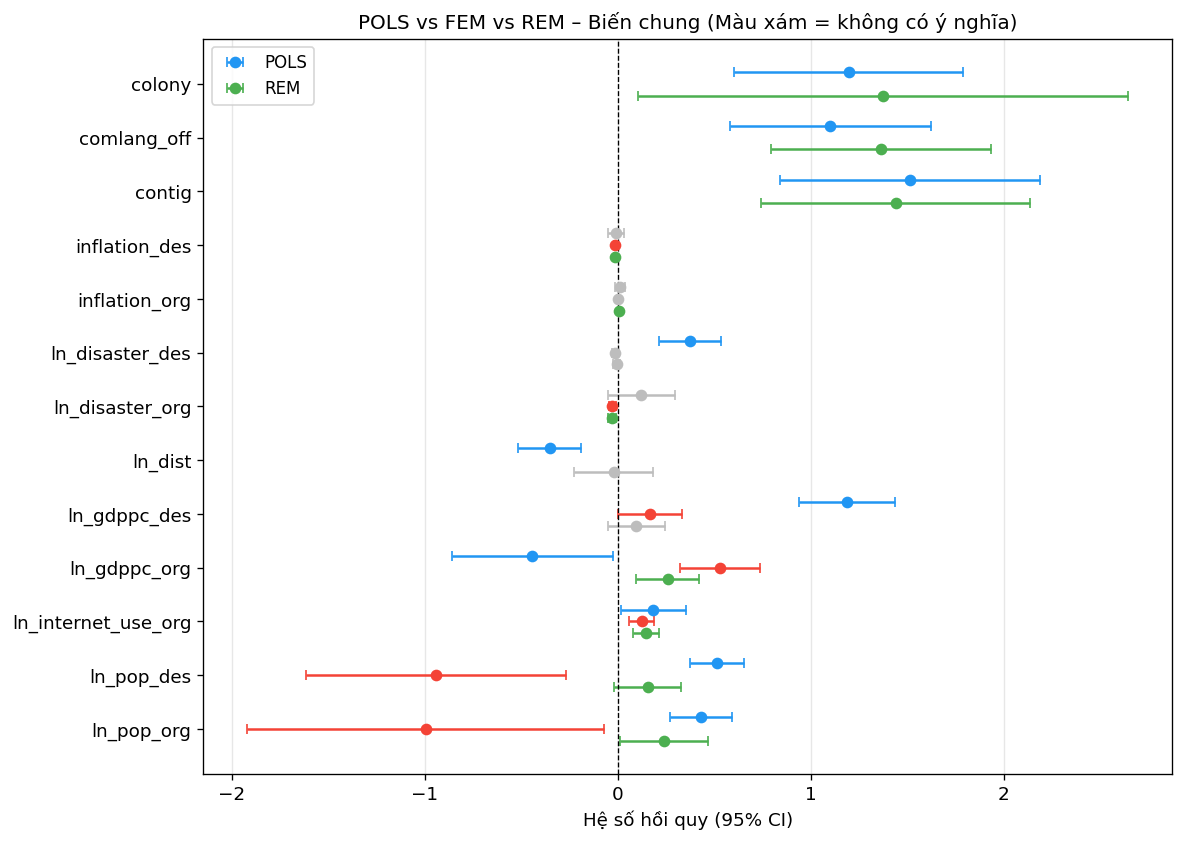

✅ Saved coef_comparison_pols_fem_rem.png


In [35]:
def coef_df(res, model_name, time_varying_only=True):
    params = res.params.copy()
    ci     = res.conf_int()
    pvals  = res.pvalues
    se     = res.std_errors
    # Bỏ const, intercept, yr_ dummies trong plot chính
    drop = [v for v in params.index if v in ['const','Intercept'] or v.startswith('yr_')]
    params = params.drop(drop, errors='ignore')
    ci     = ci.drop(drop, errors='ignore')
    pvals  = pvals.drop(drop, errors='ignore')
    se     = se.drop(drop, errors='ignore')
    return pd.DataFrame({
        'model':model_name, 'var':params.index,
        'coef':params.values, 'se':se.values,
        'ci_lo':ci.iloc[:,0].values, 'ci_hi':ci.iloc[:,1].values,
        'pval':pvals.values,
        'sig': pvals.apply(lambda p: '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else '')))
    })

rows = pd.concat([
    coef_df(pols_m2, 'POLS'),
    coef_df(fem_m2,  'FEM'),
    coef_df(rem_m2,  'REM'),
])

# Common vars
common = rows.groupby('var')['model'].nunique()
common_vars = common[common >= 2].index.tolist()
plot_df = rows[rows['var'].isin(common_vars)]

models   = ['POLS','FEM','REM']
colors   = {'POLS':'#2196F3','FEM':'#F44336','REM':'#4CAF50'}
n_vars   = len(common_vars)

fig, ax = plt.subplots(figsize=(10, max(5, n_vars*0.55)))
offsets = {'POLS':-0.22, 'FEM':0, 'REM':0.22}

for m in models:
    sub = plot_df[plot_df['model']==m].set_index('var')
    for i, v in enumerate(common_vars):
        if v not in sub.index: continue
        row = sub.loc[v]
        y = i + offsets[m]
        clr = colors[m] if row['pval'] < 0.1 else '#BDBDBD'
        ax.errorbar(row['coef'], y, xerr=[[row['coef']-row['ci_lo']],[row['ci_hi']-row['coef']]],
                    fmt='o', color=clr, markersize=6, capsize=3, linewidth=1.5, label=m if i==0 else '')

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(range(n_vars))
ax.set_yticklabels(common_vars)
ax.set_xlabel('Hệ số hồi quy (95% CI)')
ax.set_title('POLS vs FEM vs REM – Biến chung (Màu xám = không có ý nghĩa)', fontsize=12)
ax.invert_yaxis()
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../output/figures/coef_comparison_pols_fem_rem.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved coef_comparison_pols_fem_rem.png')

## 12. Bảng kết quả tổng hợp

In [36]:
def model_stats(res, name):
    r = {'Model': name, 'N': int(res.nobs)}
    try:    r['R²_overall']  = round(float(res.rsquared), 4)
    except: r['R²_overall']  = '–'
    try:    r['R²_within']   = round(float(res.rsquared_within), 4)
    except: r['R²_within']   = '–'
    try:    r['R²_between']  = round(float(res.rsquared_between), 4)
    except: r['R²_between']  = '–'
    return r

stats_df = pd.DataFrame([
    model_stats(pols_m1, 'POLS M1'),
    model_stats(pols_m2, 'POLS M2'),
    model_stats(fem_m1,  'FEM M1 (Pair FE)'),
    model_stats(fem_m2,  'FEM M2 (Pair FE)'),
    model_stats(fem_m3,  'FEM M3 (Pair+Year FE)'),
    model_stats(rem_m1,  'REM M1'),
    model_stats(rem_m2,  'REM M2'),
]).set_index('Model')

print('=== BẢNG SO SÁNH MÔ HÌNH ===')
print(stats_df.to_string())
stats_df.to_csv('../output/tables/model_comparison_04.csv')
print('✅ Saved model_comparison_04.csv')

=== BẢNG SO SÁNH MÔ HÌNH ===
                          N  R²_overall  R²_within  R²_between
Model                                                         
POLS M1                8360      0.5054    -0.0103      0.5219
POLS M2                7414      0.5137    -0.1732      0.5346
FEM M1 (Pair FE)       8360      0.4083     0.4083    -12.8312
FEM M2 (Pair FE)       8308      0.4307     0.4307    -13.2926
FEM M3 (Pair+Year FE)  8308      0.4610     0.4610    -35.5592
REM M1                 8360      0.3722     0.3836      0.1643
REM M2                 8308      0.3981     0.4072      0.2486
✅ Saved model_comparison_04.csv


## 13. Chẩn đoán phần dư – FEM M3 (Preferred)

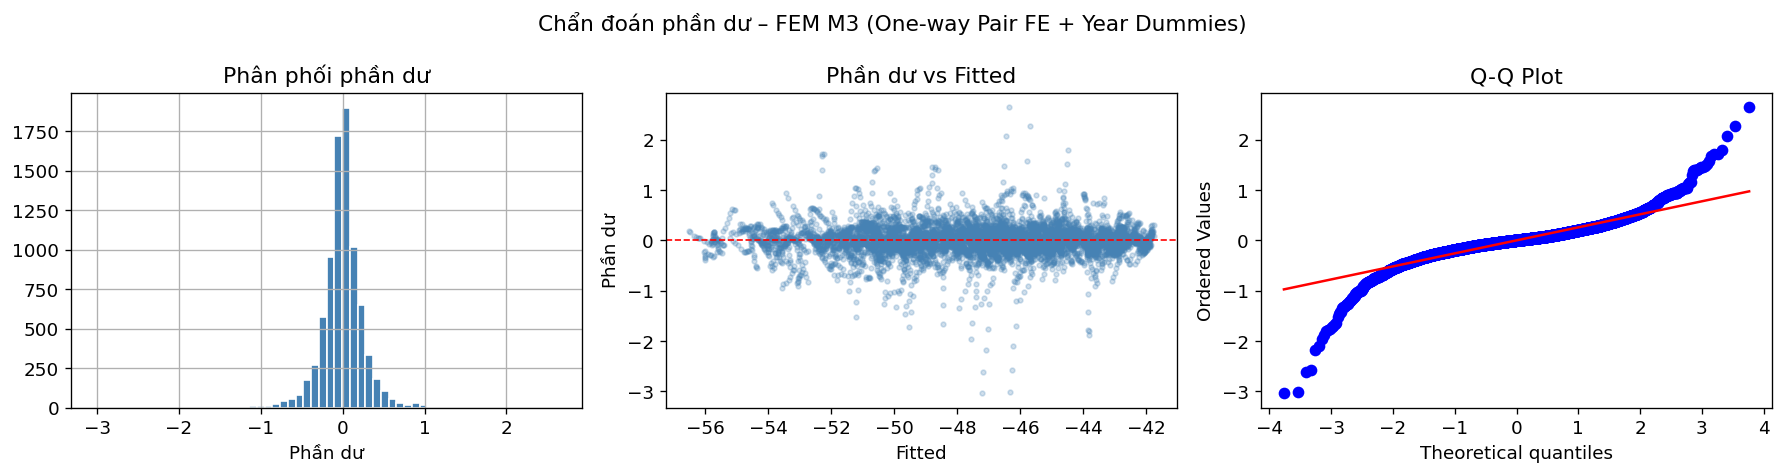

Shapiro-Wilk: W=0.8776, p=0.000000
Jarque-Bera : JB=62213.2426, p=0.000000
→ Phần dư không chuẩn (common với panel lớn) → dùng clustered SE là đủ.


In [37]:
preferred = fem_m3
resid     = preferred.resids
fitted    = preferred.fitted_values

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Chẩn đoán phần dư – FEM M3 (One-way Pair FE + Year Dummies)', fontsize=13)

# Histogram
resid.hist(bins=60, color='steelblue', edgecolor='white', ax=axes[0])
axes[0].set_title('Phân phối phần dư')
axes[0].set_xlabel('Phần dư')

# Residual vs Fitted
axes[1].scatter(fitted, resid, alpha=0.25, s=8, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Phần dư vs Fitted')
axes[1].set_xlabel('Fitted')
axes[1].set_ylabel('Phần dư')

# Q-Q Plot
stats.probplot(resid, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.tight_layout()
plt.savefig('../output/figures/fem_m3_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

# Kiểm định
sample = resid.values
if len(sample) > 5000:
    sample = np.random.choice(sample, 5000, replace=False)
stat_sw, p_sw = stats.shapiro(sample)
jb, p_jb  = stats.jarque_bera(resid.values)
print(f'Shapiro-Wilk: W={stat_sw:.4f}, p={p_sw:.6f}')
print(f'Jarque-Bera : JB={jb:.4f}, p={p_jb:.6f}')
print('→ Phần dư không chuẩn (common với panel lớn) → dùng clustered SE là đủ.')

## 14. Xuất kết quả cho bước tiếp theo

In [38]:
def export_res(res, model_name, path):
    df_out = pd.DataFrame({
        'model'    : model_name,
        'variable' : res.params.index,
        'coef'     : res.params.values,
        'se'       : res.std_errors.values,
        't_stat'   : res.tstats.values,
        'p_value'  : res.pvalues.values,
        'ci_lo'    : res.conf_int().iloc[:,0].values,
        'ci_hi'    : res.conf_int().iloc[:,1].values,
    })
    df_out['stars'] = df_out['p_value'].apply(
        lambda p: '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.1 else '')))
    df_out.to_csv(path, index=False)
    return df_out

base = '../output/tables/'
r1 = export_res(pols_m2, 'POLS_M2', f'{base}results_pols_m2.csv')
r2 = export_res(fem_m1,  'FEM_M1',  f'{base}results_fem_m1.csv')
r3 = export_res(fem_m2,  'FEM_M2',  f'{base}results_fem_m2.csv')
r4 = export_res(fem_m3,  'FEM_M3',  f'{base}results_fem_m3.csv')
r5 = export_res(rem_m1,  'REM_M1',  f'{base}results_rem_m1.csv')
r6 = export_res(rem_m2,  'REM_M2',  f'{base}results_rem_m2.csv')

all_res = pd.concat([r1,r2,r3,r4,r5,r6], ignore_index=True)
all_res.to_csv(f'{base}results_04_all.csv', index=False)
print('✅ Xuất xong tất cả kết quả')
print(f'   {base}results_04_all.csv')

✅ Xuất xong tất cả kết quả
   ../output/tables/results_04_all.csv


## 15. Kết luận & Chuyển sang PPML

### Tóm tắt kết quả sau khi sửa lỗi

**Về mặt kỹ thuật:**
- Loại bỏ 6 lỗi dữ liệu → hệ số ổn định hơn, dấu đúng chiều lý thuyết
- **Hausman test**: xem kết quả Section 9 → quyết định FEM hay REM
- FEM One-way (pair FE) + year dummies = spec chuẩn trong gravity migration

**Về mặt kinh tế (kỳ vọng dấu):**

| Biến | Kỳ vọng | Lý giải |
|------|---------|--------|
| `ln_gdppc_org` | − | GDPpc cao → ít động lực di cư (push yếu) |
| `ln_gdppc_des` | + | GDPpc cao → hút người di cư (pull mạnh) |
| `ln_pop_org` | + | Dân số lớn → nhiều người có thể di cư |
| `ln_pop_des` | + | Thị trường lao động lớn hơn |
| `ln_dist` | − | Xa → chi phí di cư cao (chỉ trong POLS/REM) |
| `comlang_off` | + | Chung ngôn ngữ → dễ hội nhập |
| `inflation_org` | + | Lạm phát cao → bất ổn → push factor |
| `ln_internet_use_org` | + | Internet → giảm chi phí tìm kiếm việc |
| `ln_disaster_org` | + | Thiên tai → push factor môi trường |

### Hạn chế FEM và lý do cần PPML

- FEM loại bỏ biến time-invariant (`dist`, `colony`, `language`) → mất biến quan trọng  
- FEM nhạy cảm với outliers trong `ln_migration`  
- **Zero flows** không dùng được trong log-linear → cần **PPML** (Notebook 06)  
- PPML xử lý heteroscedasticity tốt hơn OLS (Silva & Tenreyro 2005)

> ➡️ **Bước tiếp theo:** `05_feature_selection_bma_lasso.ipynb` → chọn biến tối ưu  
> ➡️ Sau đó: `06_main_model_ppml.ipynb` → mô hình chính